### Mục tiêu EDA (Tuần 1 – TV1):
1. Thống kê mô tả 3 features theo outcome
2. Phân tích class imbalance
3. Correlation heatmap
4. Baseline naive model (predict majority)
5. Stratified 5-fold CV setup
6. Experiment tracking (log file)

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats

from sklearn.dummy import DummyClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.preprocessing import label_binarize
from sklearn.metrics import (
    accuracy_score, roc_auc_score, average_precision_score,
    matthews_corrcoef, brier_score_loss, confusion_matrix,
    classification_report
)

import warnings, json, os, datetime
warnings.filterwarnings('ignore')

In [3]:
# Reproducibility
SEED = 42
np.random.seed(SEED)

# Plotting style
sns.set_theme(style='whitegrid', palette='Set2', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

print(f'   Timestamp: {datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S")}')

   Timestamp: 2026-03-19 21:04:53


---
## 1. Load & Inspect Data

In [4]:
# ── 1.1 LOAD DATA ────────────────────────────────────────────────────────────
PRIMARY_PATH    = 'D:\code\python\projects\Statitical\Sepsis\AI66A_group_6\s41598-020-73558-3_sepsis_survival_primary_cohort.csv'
STUDY_PATH      = 'D:\code\python\projects\Statitical\Sepsis\AI66A_group_6\s41598-020-73558-3_sepsis_survival_study_cohort.csv'
VALIDATION_PATH = 'D:\code\python\projects\Statitical\Sepsis\AI66A_group_6\s41598-020-73558-3_sepsis_survival_validation_cohort.csv'

df_primary    = pd.read_csv(PRIMARY_PATH)
df_study      = pd.read_csv(STUDY_PATH)
df_validation = pd.read_csv(VALIDATION_PATH)

# Rename columns for readability
COL_MAP = {
    'age_years':                      'age',
    'sex_0male_1female':              'sex',
    'episode_number':                 'episode',
    'hospital_outcome_1alive_0dead':  'outcome'
}
for df in [df_primary, df_study, df_validation]:
    df.rename(columns=COL_MAP, inplace=True)

FEATURES = ['age', 'sex', 'episode']
TARGET   = 'outcome'

print('Dataset shapes:')
print(f'  Primary cohort    : {df_primary.shape}  (Norway – full)')
print(f'  Study cohort      : {df_study.shape}  (Norway – subset)')
print(f'  Validation cohort : {df_validation.shape}  (Korea)')
print()
df_primary.head()

Dataset shapes:
  Primary cohort    : (110204, 4)  (Norway – full)
  Study cohort      : (19051, 4)  (Norway – subset)
  Validation cohort : (137, 4)  (Korea)



,age,sex,episode,outcome
0,21,1,1,1
1,20,1,1,1
2,21,1,1,1
3,77,0,1,1
4,72,0,1,1


In [5]:
# ── 1.2 BASIC INFO ───────────────────────────────────────────────────────────
print('=== Primary cohort – dtypes & nulls ===')
print(df_primary.info())
print()
print('=== Missing values ===')
print(df_primary.isnull().sum())

=== Primary cohort – dtypes & nulls ===
<class 'pandas.DataFrame'>
RangeIndex: 110204 entries, 0 to 110203
Data columns (total 4 columns):
 #   Column   Non-Null Count   Dtype
---  ------   --------------   -----
 0   age      110204 non-null  int64
 1   sex      110204 non-null  int64
 2   episode  110204 non-null  int64
 3   outcome  110204 non-null  int64
dtypes: int64(4)
memory usage: 3.4 MB
None

=== Missing values ===
age        0
sex        0
episode    0
outcome    0
dtype: int64


---
## 2. Descriptive Statistics

In [6]:
# ── 2.1 OVERALL DESCRIPTIVE STATS ────────────────────────────────────────────
print('=== Descriptive stats – Primary cohort ===')
display(df_primary.describe().T.round(3))

=== Descriptive stats – Primary cohort ===


,count,mean,std,min,25%,50%,75%,max
age,110204.0,62.735,24.127,0.0,51.0,68.0,81.0,100.0
sex,110204.0,0.474,0.499,0.0,0.0,0.0,1.0,1.0
episode,110204.0,1.349,0.752,1.0,1.0,1.0,1.0,5.0
outcome,110204.0,0.926,0.261,0.0,1.0,1.0,1.0,1.0


In [7]:
# ── 2.2 STATS STRATIFIED BY OUTCOME ─────────────────────────────────────────
print('=== Descriptive stats stratified by outcome (1=Alive, 0=Dead) ===')
display(
    df_primary.groupby('outcome')[FEATURES]
    .agg(['mean','median','std','min','max'])
    .round(3)
)

=== Descriptive stats stratified by outcome (1=Alive, 0=Dead) ===


age                            sex                       episode  \
           mean median     std min  max   mean median    std min max    mean   
outcome                                                                        
0        77.300   80.0  13.810   0  100  0.439    0.0  0.496   0   1   1.367   
1        61.579   67.0  24.393   0  100  0.477    0.0  0.499   0   1   1.348   

                               
        median    std min max  
outcome                        
0          1.0  0.744   1   5  
1          1.0  0.752   1   5

In [8]:
# ── 2.3 AGE BUCKET ANALYSIS ──────────────────────────────────────────────────
age_bins   = [0, 18, 40, 60, 75, 120]
age_labels = ['<18', '18-40', '40-60', '60-75', '75+']

df_primary['age_group'] = pd.cut(
    df_primary['age'], bins=age_bins, labels=age_labels, right=False
)

age_outcome = (
    df_primary.groupby('age_group', observed=True)['outcome']
    .agg(['count', 'sum', 'mean'])
    .rename(columns={'count':'n_total', 'sum':'n_alive', 'mean':'survival_rate'})
)
age_outcome['n_dead']       = age_outcome['n_total'] - age_outcome['n_alive']
age_outcome['mortality_rate'] = 1 - age_outcome['survival_rate']

print('=== Survival rate by age group ===')
display(age_outcome.round(4))

=== Survival rate by age group ===


,n_total,n_alive,survival_rate,n_dead,mortality_rate
age_group,,,,,
<18,7815,7761,0.9931,54,0.0069
18-40,11016,10936,0.9927,80,0.0073
40-60,18812,18223,0.9687,589,0.0313
60-75,29724,27646,0.9301,2078,0.0699
75+,42837,37533,0.8762,5304,0.1238



## 3. Class Imbalance Analysis

In [9]:
# ── 3.1 CLASS DISTRIBUTION ───────────────────────────────────────────────────
def imbalance_report(df, name):
    vc = df['outcome'].value_counts()
    total = len(df)
    n_alive = vc.get(1, 0)
    n_dead  = vc.get(0, 0)
    ratio   = n_alive / n_dead if n_dead > 0 else float('inf')
    print(f'[{name}]')
    print(f'  Total    : {total:,}')
    print(f'  Alive (1): {n_alive:,}  ({n_alive/total*100:.2f}%)')
    print(f'  Dead  (0): {n_dead:,}  ({n_dead/total*100:.2f}%)')
    print(f'  Imbalance ratio (alive/dead): {ratio:.2f}:1')
    print()

imbalance_report(df_primary,    'Primary cohort (Norway)')
imbalance_report(df_study,      'Study cohort (Norway)')
imbalance_report(df_validation, 'Validation cohort (Korea)')

[Primary cohort (Norway)]
  Total    : 110,204
  Alive (1): 102,099  (92.65%)
  Dead  (0): 8,105  (7.35%)
  Imbalance ratio (alive/dead): 12.60:1

[Study cohort (Norway)]
  Total    : 19,051
  Alive (1): 15,445  (81.07%)
  Dead  (0): 3,606  (18.93%)
  Imbalance ratio (alive/dead): 4.28:1

[Validation cohort (Korea)]
  Total    : 137
  Alive (1): 113  (82.48%)
  Dead  (0): 24  (17.52%)
  Imbalance ratio (alive/dead): 4.71:1



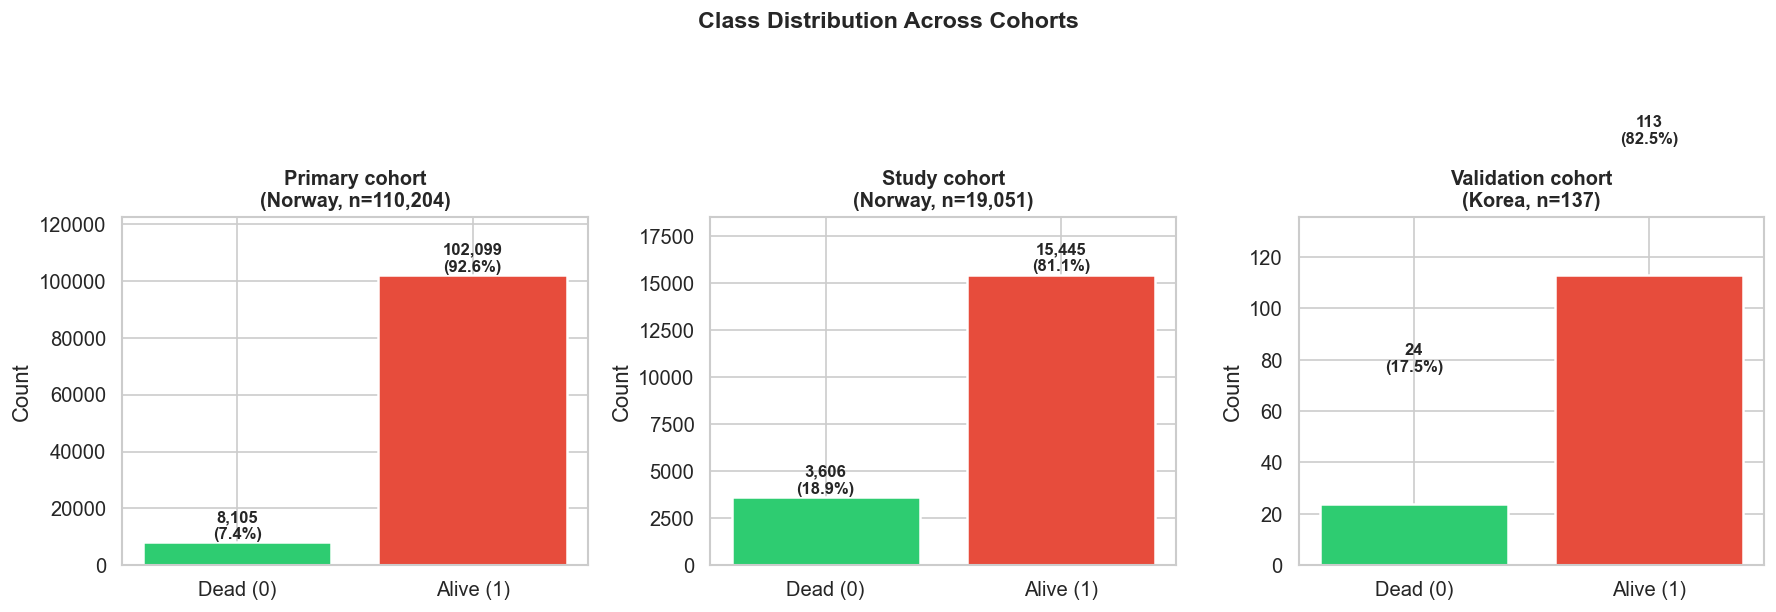

In [10]:
# ── 3.2 VISUALISE CLASS IMBALANCE ────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
datasets  = [
    (df_primary,    'Primary cohort\n(Norway, n=110,204)'),
    (df_study,      'Study cohort\n(Norway, n=19,051)'),
    (df_validation, 'Validation cohort\n(Korea, n=137)')
]
colors = ['#2ecc71', '#e74c3c']

for ax, (df, title) in zip(axes, datasets):
    counts = df['outcome'].value_counts().sort_index()
    bars   = ax.bar(['Dead (0)', 'Alive (1)'], counts.values,
                    color=colors, edgecolor='white', linewidth=1.5)
    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                f'{val:,}\n({val/len(df)*100:.1f}%)',
                ha='center', va='bottom', fontsize=10, fontweight='bold')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylabel('Count')
    ax.set_ylim(0, counts.max() * 1.2)

plt.suptitle('Class Distribution Across Cohorts', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 4. Feature Distribution Analysis

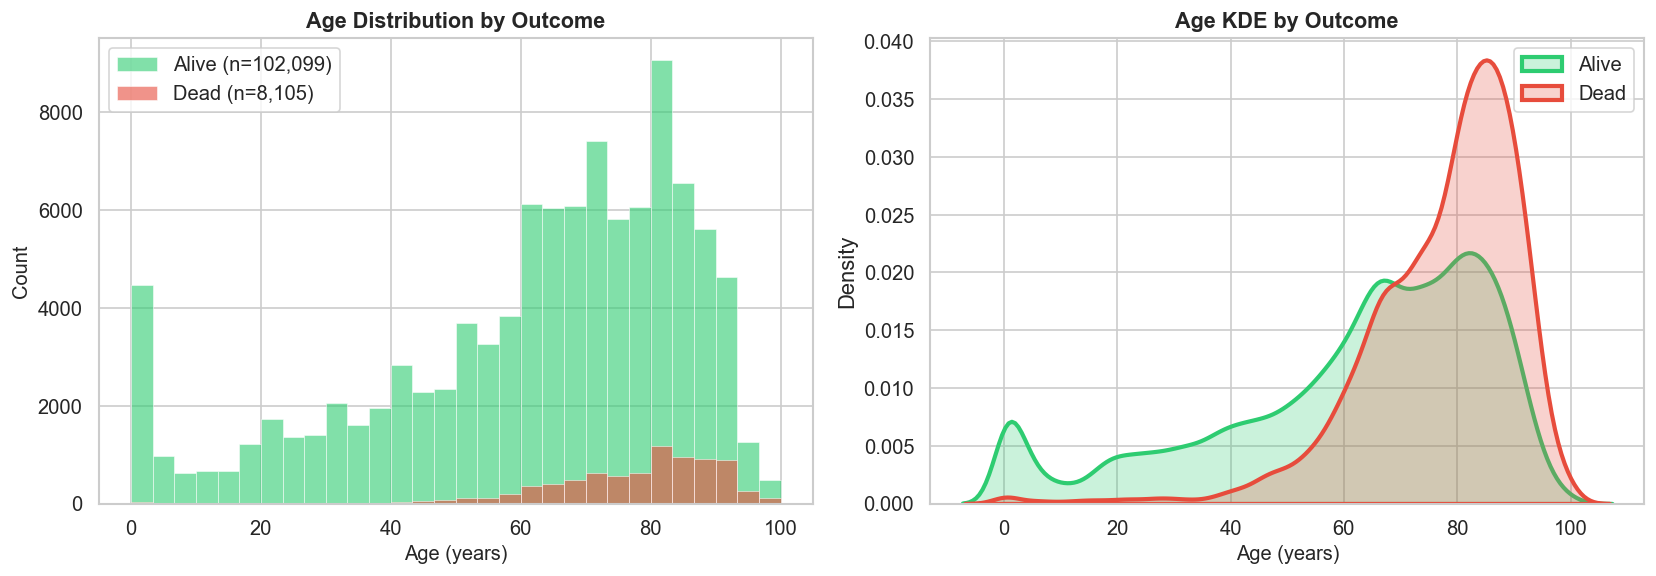

In [11]:
# ── 4.1 AGE DISTRIBUTION BY OUTCOME ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
for outcome, color, label in [(1,'#2ecc71','Alive'), (0,'#e74c3c','Dead')]:
    subset = df_primary[df_primary['outcome'] == outcome]['age']
    axes[0].hist(subset, bins=30, alpha=0.6, color=color, label=f'{label} (n={len(subset):,})',
                 edgecolor='white', linewidth=0.5)
axes[0].set_xlabel('Age (years)', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].set_title('Age Distribution by Outcome', fontsize=13, fontweight='bold')
axes[0].legend()

# KDE
for outcome, color, label in [(1,'#2ecc71','Alive'), (0,'#e74c3c','Dead')]:
    subset = df_primary[df_primary['outcome'] == outcome]['age']
    sns.kdeplot(subset, ax=axes[1], color=color, label=label, linewidth=2.5, fill=True, alpha=0.25)
axes[1].set_xlabel('Age (years)', fontsize=12)
axes[1].set_title('Age KDE by Outcome', fontsize=13, fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()

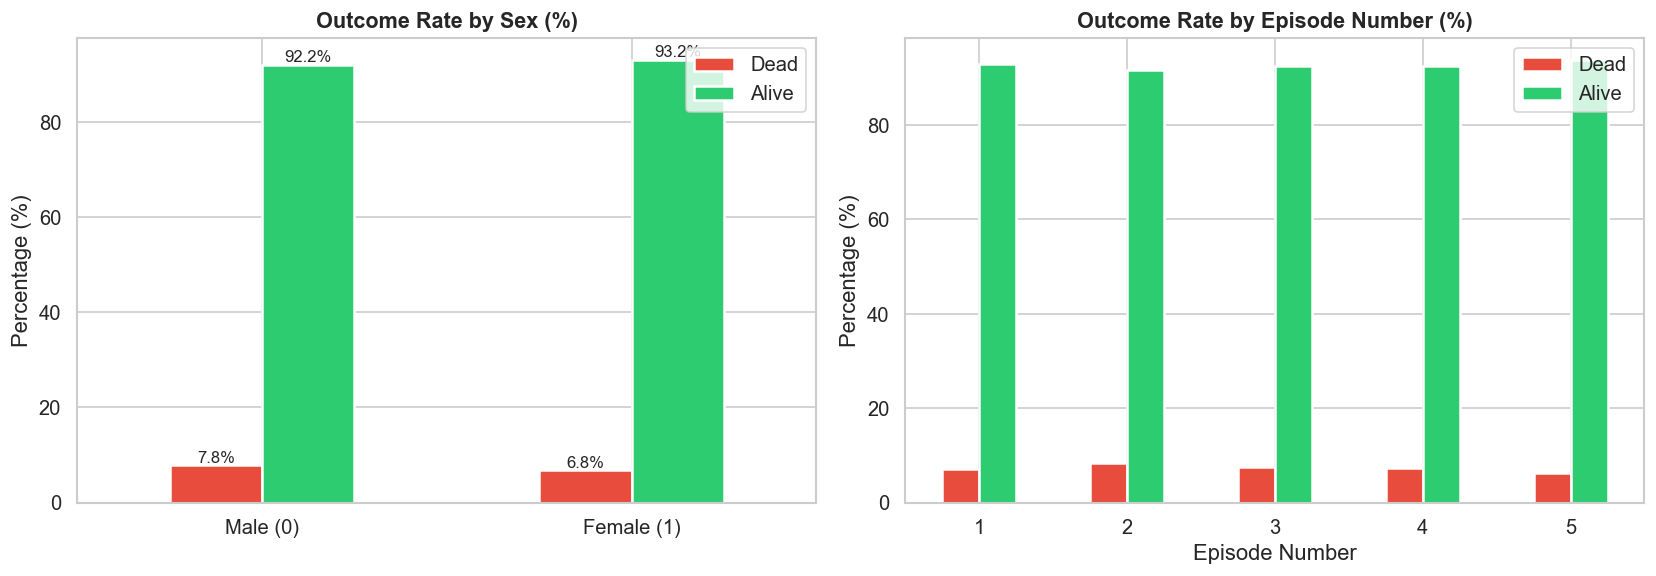

In [12]:
# ── 4.2 SEX & EPISODE DISTRIBUTION BY OUTCOME ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sex
sex_outcome = df_primary.groupby(['sex','outcome']).size().unstack(fill_value=0)
sex_outcome.index = ['Male (0)', 'Female (1)']
sex_outcome.columns = ['Dead', 'Alive']
sex_outcome_pct = sex_outcome.div(sex_outcome.sum(axis=1), axis=0) * 100
sex_outcome_pct.plot(kind='bar', ax=axes[0], color=['#e74c3c','#2ecc71'],
                     edgecolor='white', linewidth=1.5, rot=0)
axes[0].set_title('Outcome Rate by Sex (%)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Percentage (%)')
axes[0].legend(loc='upper right')
for p in axes[0].patches:
    axes[0].annotate(f'{p.get_height():.1f}%',
                     (p.get_x() + p.get_width()/2, p.get_height()),
                     ha='center', va='bottom', fontsize=10)

# Episode number (top 5)
ep_outcome = df_primary.groupby(['episode','outcome']).size().unstack(fill_value=0)
ep_outcome.columns = ['Dead','Alive']
ep_outcome_pct = ep_outcome.div(ep_outcome.sum(axis=1), axis=0) * 100
ep_outcome_pct = ep_outcome_pct.loc[ep_outcome_pct.index <= 5]
ep_outcome_pct.plot(kind='bar', ax=axes[1], color=['#e74c3c','#2ecc71'],
                    edgecolor='white', linewidth=1.5, rot=0)
axes[1].set_title('Outcome Rate by Episode Number (%)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Episode Number')
axes[1].set_ylabel('Percentage (%)')
axes[1].legend(loc='upper right')

plt.tight_layout()
plt.show()

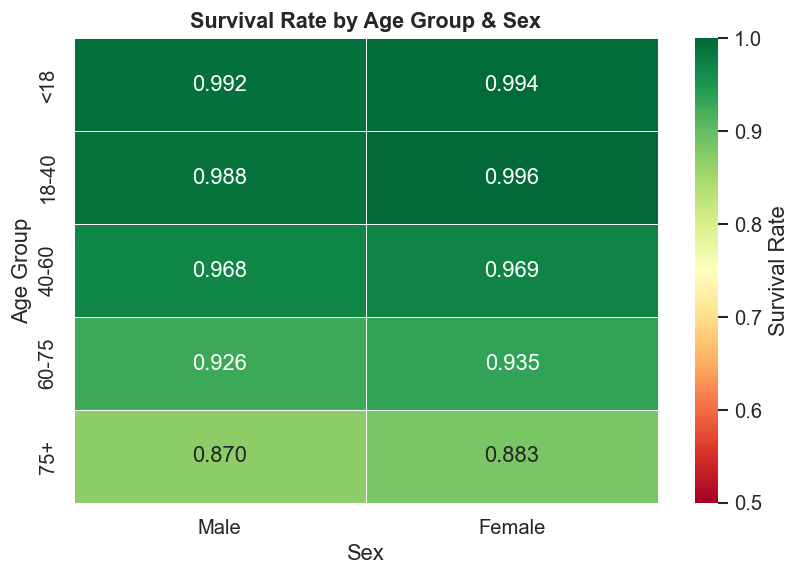

In [13]:
# ── 4.3 SURVIVAL RATE BY AGE GROUP (HEATMAP STYLE) ───────────────────────────
pivot_age_sex = df_primary.groupby(['age_group', 'sex'], observed=True)['outcome'].mean().unstack()
pivot_age_sex.columns = ['Male', 'Female']

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(pivot_age_sex, annot=True, fmt='.3f', cmap='RdYlGn',
            linewidths=0.5, linecolor='white',
            vmin=0.5, vmax=1.0, ax=ax, cbar_kws={'label': 'Survival Rate'})
ax.set_title('Survival Rate by Age Group & Sex', fontsize=13, fontweight='bold')
ax.set_xlabel('Sex')
ax.set_ylabel('Age Group')
plt.tight_layout()
plt.show()


## 5. Correlation Heatmap

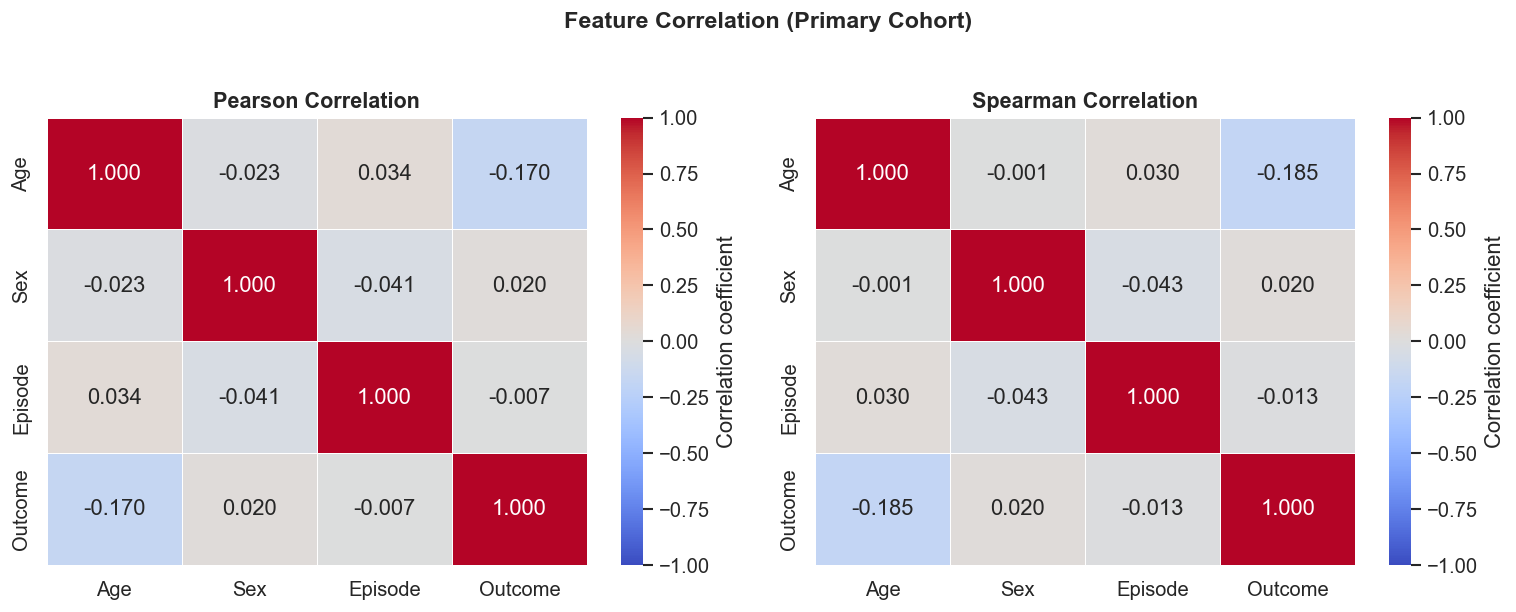


=== Pearson Correlation with Outcome ===
Age       -0.170088
Episode   -0.006764
Sex        0.019796
Name: Outcome, dtype: float64


In [14]:
# ── 5. CORRELATION HEATMAP ────────────────────────────────────────────────────
corr_df = df_primary[FEATURES + [TARGET]].copy()
corr_df.columns = ['Age', 'Sex', 'Episode', 'Outcome']

corr_matrix = corr_df.corr(method='pearson')
spearman_matrix = corr_df.corr(method='spearman')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)

for ax, mat, title in zip(axes,
                          [corr_matrix, spearman_matrix],
                          ['Pearson Correlation', 'Spearman Correlation']):
    sns.heatmap(mat, annot=True, fmt='.3f', cmap='coolwarm',
                linewidths=0.5, linecolor='white',
                vmin=-1, vmax=1, center=0, ax=ax,
                cbar_kws={'label': 'Correlation coefficient'})
    ax.set_title(title, fontsize=13, fontweight='bold')

plt.suptitle('Feature Correlation (Primary Cohort)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
print()
print('=== Pearson Correlation with Outcome ===')
print(corr_matrix['Outcome'].drop('Outcome').sort_values())

# OUTLIER DETECTION 

In [15]:
from scipy.stats import zscore
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor


In [16]:

# ── A. Z-SCORE (chỉ áp dụng cho 'age' vì là continuous) ─────────────────────
z_scores = np.abs(zscore(df_primary['age']))
outliers_zscore = (z_scores > 3).sum()
print(f"[Z-Score |z|>3] Age outliers: {outliers_zscore:,} ({outliers_zscore/len(df_primary)*100:.2f}%)")


[Z-Score |z|>3] Age outliers: 0 (0.00%)


In [17]:

# ── B. IQR METHOD (age & episode) ────────────────────────────────────────────
def iqr_outliers(series):
    Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
    IQR = Q3 - Q1
    return ((series < Q1 - 1.5*IQR) | (series > Q3 + 1.5*IQR)).sum()

for col in ['age', 'episode']:
    n = iqr_outliers(df_primary[col])
    print(f"[IQR 1.5x]      {col} outliers: {n:,} ({n/len(df_primary)*100:.2f}%)")


[IQR 1.5x]      age outliers: 5,230 (4.75%)
[IQR 1.5x]      episode outliers: 25,393 (23.04%)


In [18]:

# ── C. ISOLATION FOREST (multivariate) ───────────────────────────────────────
iso = IsolationForest(contamination=0.05, random_state=SEED, n_jobs=-1)
iso_labels = iso.fit_predict(df_primary[FEATURES])          # -1 = outlier
n_iso = (iso_labels == -1).sum()
print(f"[IsolationForest] Multivariate outliers: {n_iso:,} ({n_iso/len(df_primary)*100:.2f}%)")


[IsolationForest] Multivariate outliers: 5,501 (4.99%)


In [19]:

# ── D. LOCAL OUTLIER FACTOR (multivariate) ───────────────────────────────────
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05, n_jobs=-1)
lof_labels = lof.fit_predict(df_primary[FEATURES])          # -1 = outlier
n_lof = (lof_labels == -1).sum()
print(f"[LOF n=20]        Multivariate outliers: {n_lof:,} ({n_lof/len(df_primary)*100:.2f}%)")


[LOF n=20]        Multivariate outliers: 2,376 (2.16%)


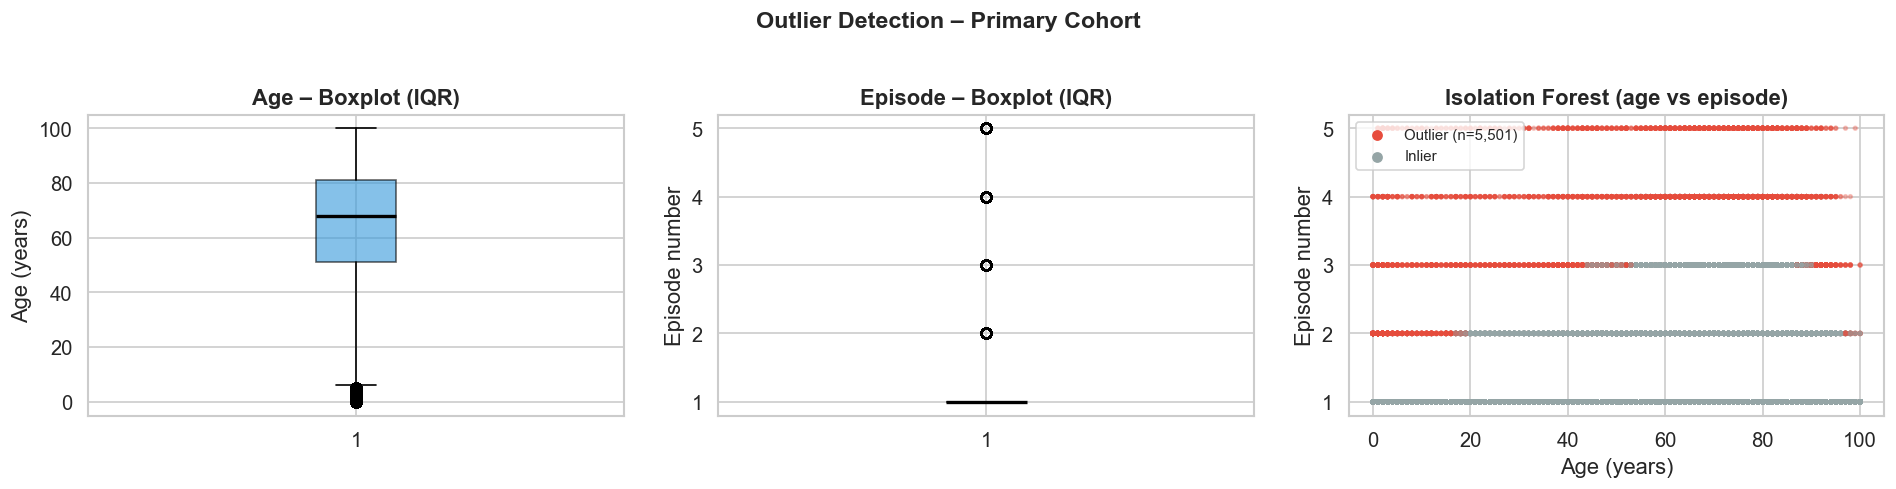

In [20]:

# ── E. VISUALISE ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# E1. Age boxplot (IQR)
bp = axes[0].boxplot(df_primary['age'], vert=True, patch_artist=True,
                     boxprops=dict(facecolor='#3498db', alpha=0.6),
                     medianprops=dict(color='black', linewidth=2))
axes[0].set_title('Age – Boxplot (IQR)', fontweight='bold')
axes[0].set_ylabel('Age (years)')

# E2. Episode boxplot (IQR)
axes[1].boxplot(df_primary['episode'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='#e67e22', alpha=0.6),
                medianprops=dict(color='black', linewidth=2))
axes[1].set_title('Episode – Boxplot (IQR)', fontweight='bold')
axes[1].set_ylabel('Episode number')

# E3. Isolation Forest: age vs episode, tô màu outlier
colors_iso = np.where(iso_labels == -1, '#e74c3c', '#95a5a6')
axes[2].scatter(df_primary['age'], df_primary['episode'],
                c=colors_iso, alpha=0.3, s=5)
axes[2].scatter([], [], c='#e74c3c', label=f'Outlier (n={n_iso:,})', s=30)
axes[2].scatter([], [], c='#95a5a6', label='Inlier', s=30)
axes[2].set_title('Isolation Forest (age vs episode)', fontweight='bold')
axes[2].set_xlabel('Age (years)')
axes[2].set_ylabel('Episode number')
axes[2].legend(fontsize=9)

plt.suptitle('Outlier Detection – Primary Cohort', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


In [21]:

# ── F. SUMMARY TABLE ─────────────────────────────────────────────────────────
print("\n=== SUMMARY ===")
summary = pd.DataFrame({
    'Method':        ['Z-Score (age)', 'IQR (age)', 'IQR (episode)',
                      'Isolation Forest', 'LOF'],
    'N outliers':    [outliers_zscore, iqr_outliers(df_primary['age']),
                      iqr_outliers(df_primary['episode']), n_iso, n_lof],
    'Scope':         ['Univariate', 'Univariate', 'Univariate',
                      'Multivariate', 'Multivariate'],
})
summary['% of data'] = (summary['N outliers'] / len(df_primary) * 100).round(3)
display(summary)
print("\n⚠️  Lưu ý: sex là binary (0/1) → không áp dụng outlier detection.")
print("   Multivariate outliers nên xem xét kỹ trước khi loại bỏ vì")
print("   dataset y tế – extreme values có thể là clinical signal thực.")


=== SUMMARY ===


,Method,N outliers,Scope,% of data
0,Z-Score (age),0,Univariate,0.000
1,IQR (age),5230,Univariate,4.746
2,IQR (episode),25393,Univariate,23.042
3,Isolation Forest,5501,Multivariate,4.992
4,LOF,2376,Multivariate,2.156



⚠️  Lưu ý: sex là binary (0/1) → không áp dụng outlier detection.
   Multivariate outliers nên xem xét kỹ trước khi loại bỏ vì
   dataset y tế – extreme values có thể là clinical signal thực.


---
## 6. Baseline Naive Model (Predict Majority)

In [22]:
# ── 6. BASELINE NAIVE MODELS ─────────────────────────────────────────────────
X = df_primary[FEATURES].values
y = df_primary[TARGET].values

X_val = df_validation[FEATURES].values
y_val = df_validation[TARGET].values

baseline_strategies = {
    'Majority class (most_frequent)': DummyClassifier(strategy='most_frequent', random_state=SEED),
    'Stratified random':              DummyClassifier(strategy='stratified',     random_state=SEED),
    'Uniform random':                 DummyClassifier(strategy='uniform',        random_state=SEED),
}

print('=== Baseline Models on Primary Cohort (5-fold CV) ===\n')
results_baseline = []
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

for name, clf in baseline_strategies.items():
    cv_res = cross_validate(
        clf, X, y, cv=skf,
        scoring=['accuracy', 'roc_auc', 'average_precision', 'f1'],
        return_train_score=False
    )
    row = {
        'Model':      name,
        'Accuracy':   cv_res['test_accuracy'].mean(),
        'AUROC':      cv_res['test_roc_auc'].mean(),
        'PR-AUC':     cv_res['test_average_precision'].mean(),
        'F1':         cv_res['test_f1'].mean(),
    }
    results_baseline.append(row)
    print(f"  {name}")
    print(f"    Accuracy : {row['Accuracy']:.4f}")
    print(f"    AUROC    : {row['AUROC']:.4f}")
    print(f"    PR-AUC   : {row['PR-AUC']:.4f}")
    print(f"    F1       : {row['F1']:.4f}")
    print()

df_baseline = pd.DataFrame(results_baseline)
df_baseline.to_csv('baseline_results.csv', index=False)

=== Baseline Models on Primary Cohort (5-fold CV) ===

  Majority class (most_frequent)
    Accuracy : 0.9265
    AUROC    : 0.5000
    PR-AUC   : 0.9265
    F1       : 0.9618

  Stratified random
    Accuracy : 0.8625
    AUROC    : 0.5019
    PR-AUC   : 0.9267
    F1       : 0.9257

  Uniform random
    Accuracy : 0.4995
    AUROC    : 0.5000
    PR-AUC   : 0.9265
    F1       : 0.6493



In [23]:
# ── 6.2 MCC & BRIER SCORE FOR MAJORITY BASELINE ──────────────────────────────
majority_clf = DummyClassifier(strategy='most_frequent', random_state=SEED)
majority_clf.fit(X, y)
y_pred = majority_clf.predict(X)
y_prob = majority_clf.predict_proba(X)[:, 1]

print('=== Majority Baseline – Full Primary Cohort ===')
print(f'  MCC         : {matthews_corrcoef(y, y_pred):.4f}')
print(f'  Brier Score : {brier_score_loss(y, y_prob):.4f}')
print()
print('=== Confusion Matrix (Majority Baseline) ===')
print(confusion_matrix(y, y_pred))
print()
print(classification_report(y, y_pred, target_names=['Dead','Alive']))

=== Majority Baseline – Full Primary Cohort ===
  MCC         : 0.0000
  Brier Score : 0.0735

=== Confusion Matrix (Majority Baseline) ===
[[     0   8105]
 [     0 102099]]

              precision    recall  f1-score   support

        Dead       0.00      0.00      0.00      8105
       Alive       0.93      1.00      0.96    102099

    accuracy                           0.93    110204
   macro avg       0.46      0.50      0.48    110204
weighted avg       0.86      0.93      0.89    110204



---
## 7. Stratified 5-Fold CV Setup

In [24]:
# ── 7. STRATIFIED K-FOLD SETUP & DISTRIBUTION VERIFICATION ───────────────────
print('=== Stratified 5-Fold CV – Class Distribution Check ===')
print(f'Overall class ratio: {y.mean():.4f} (alive fraction)\n')

fold_stats = []
for fold_idx, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
    y_train_fold = y[train_idx]
    y_val_fold   = y[val_idx]
    row = {
        'Fold': fold_idx,
        'Train size':      len(train_idx),
        'Val size':        len(val_idx),
        'Train alive%':    y_train_fold.mean() * 100,
        'Val alive%':      y_val_fold.mean() * 100,
        'Train dead count': (y_train_fold == 0).sum(),
        'Val dead count':   (y_val_fold == 0).sum(),
    }
    fold_stats.append(row)
    print(f"  Fold {fold_idx}: train={len(train_idx):,} (alive={y_train_fold.mean():.4f}) | "
          f"val={len(val_idx):,} (alive={y_val_fold.mean():.4f})")

df_folds = pd.DataFrame(fold_stats)
print()
print('=== Distribution shift across folds (std) ===')
print(f"  Train alive% std: {df_folds['Train alive%'].std():.4f}%")
print(f"  Val alive% std  : {df_folds['Val alive%'].std():.4f}%")
print('  → Low std confirms stratification is working correctly ✅')

=== Stratified 5-Fold CV – Class Distribution Check ===
Overall class ratio: 0.9265 (alive fraction)

  Fold 1: train=88,163 (alive=0.9265) | val=22,041 (alive=0.9265)
  Fold 2: train=88,163 (alive=0.9265) | val=22,041 (alive=0.9265)
  Fold 3: train=88,163 (alive=0.9265) | val=22,041 (alive=0.9265)
  Fold 4: train=88,163 (alive=0.9265) | val=22,041 (alive=0.9265)
  Fold 5: train=88,164 (alive=0.9265) | val=22,040 (alive=0.9265)

=== Distribution shift across folds (std) ===
  Train alive% std: 0.0000%
  Val alive% std  : 0.0001%
  → Low std confirms stratification is working correctly ✅


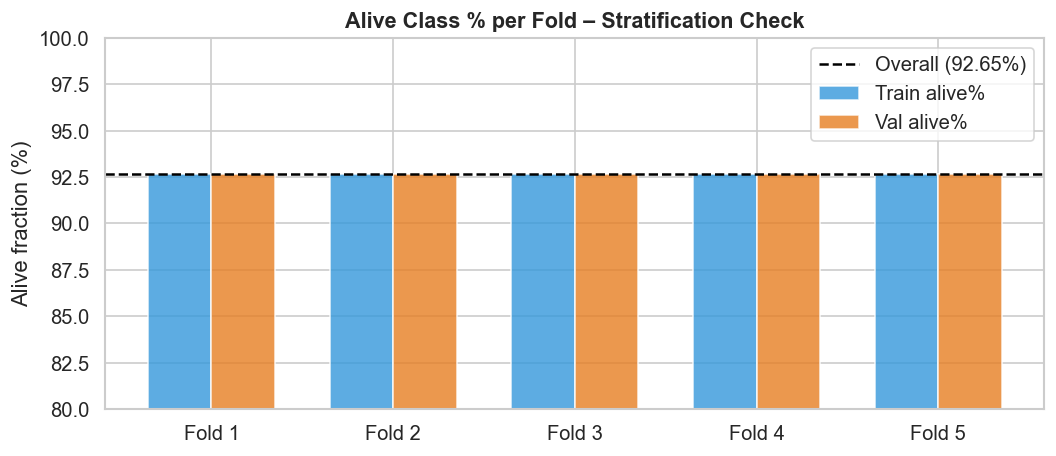

In [25]:
# ── 7.2 VISUALISE FOLD DISTRIBUTION ──────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4))
folds = df_folds['Fold'].tolist()
x = np.arange(len(folds))
width = 0.35

ax.bar(x - width/2, df_folds['Train alive%'], width,
       label='Train alive%', color='#3498db', alpha=0.8, edgecolor='white')
ax.bar(x + width/2, df_folds['Val alive%'], width,
       label='Val alive%', color='#e67e22', alpha=0.8, edgecolor='white')
ax.axhline(y=y.mean()*100, color='black', linestyle='--', linewidth=1.5,
           label=f'Overall ({y.mean()*100:.2f}%)')
ax.set_xticks(x)
ax.set_xticklabels([f'Fold {i}' for i in folds])
ax.set_ylabel('Alive fraction (%)')
ax.set_title('Alive Class % per Fold – Stratification Check', fontsize=13, fontweight='bold')
ax.legend()
ax.set_ylim(80, 100)
plt.tight_layout()
plt.show()

---
## 8. Experiment Tracking Log

In [26]:
# ── 8. EXPERIMENT LOG (JSON format – MLflow-compatible) ───────────────────────
experiment_log = {
    'experiment': 'sepsis_eda_baseline',
    'timestamp':  datetime.datetime.now().isoformat(),
    'seed':       SEED,
    'dataset': {
        'primary_n':    int(len(df_primary)),
        'study_n':      int(len(df_study)),
        'validation_n': int(len(df_validation)),
        'features':     FEATURES,
        'target':       TARGET,
        'primary_alive_pct':   float(round(df_primary['outcome'].mean() * 100, 4)),
        'primary_dead_pct':    float(round((1 - df_primary['outcome'].mean()) * 100, 4)),
        'imbalance_ratio':     float(round(
            df_primary['outcome'].sum() / (len(df_primary) - df_primary['outcome'].sum()), 4
        )),
    },
    'baseline_models': results_baseline,
    'cv_setup': {
        'strategy':  'StratifiedKFold',
        'n_splits':  5,
        'shuffle':   True,
        'random_state': SEED
    },
    'notes': [
        'Bayes error bound to be derived in Week 1 – TV2 (Stats Lead)',
        'SMOTE ablation scheduled for Week 2',
        'Calibration analysis scheduled for Week 2',
        'Fairness audit scheduled for Week 2'
    ]
}

with open('experiment_log_week1.json', 'w', encoding='utf-8') as f:
    json.dump(experiment_log, f, indent=2, ensure_ascii=False)

print(json.dumps(experiment_log, indent=2, ensure_ascii=False))

{
  "experiment": "sepsis_eda_baseline",
  "timestamp": "2026-03-19T21:05:08.664738",
  "seed": 42,
  "dataset": {
    "primary_n": 110204,
    "study_n": 19051,
    "validation_n": 137,
    "features": [
      "age",
      "sex",
      "episode"
    ],
    "target": "outcome",
    "primary_alive_pct": 92.6455,
    "primary_dead_pct": 7.3545,
    "imbalance_ratio": 12.597
  },
  "baseline_models": [
    {
      "Model": "Majority class (most_frequent)",
      "Accuracy": 0.926454575127314,
      "AUROC": 0.5,
      "PR-AUC": 0.926454575127314,
      "F1": 0.9618234315912766
    },
    {
      "Model": "Stratified random",
      "Accuracy": 0.8624550954412544,
      "AUROC": 0.5018643798384673,
      "PR-AUC": 0.9267090383279157,
      "F1": 0.925684428172169
    },
    {
      "Model": "Uniform random",
      "Accuracy": 0.4994555526818482,
      "AUROC": 0.5,
      "PR-AUC": 0.926454575127314,
      "F1": 0.649270715600705
    }
  ],
  "cv_setup": {
    "strategy": "StratifiedKFold",


---
## 9. Summary & Handoff to TV2

In [27]:
# ── 9. SUMMARY TABLE ─────────────────────────────────────────────────────────
print('=' * 65)
print('  TUẦN 1 – TV1 EDA SUMMARY')
print('=' * 65)
print(f"  Primary cohort    : {len(df_primary):,} admissions")
print(f"  Alive (class 1)   : {df_primary['outcome'].sum():,}  "
      f"({df_primary['outcome'].mean()*100:.2f}%)")
print(f"  Dead  (class 0)   : {(df_primary['outcome']==0).sum():,}  "
      f"({(df_primary['outcome']==0).mean()*100:.2f}%)")
print(f"  Imbalance ratio   : {experiment_log['dataset']['imbalance_ratio']:.2f}:1 (alive/dead)")
print()
print('  Age stats (primary):')
print(f"    Mean  : {df_primary['age'].mean():.1f} years")
print(f"    Median: {df_primary['age'].median():.1f} years")
print(f"    Std   : {df_primary['age'].std():.1f} years")
print(f"    Range : {df_primary['age'].min()}–{df_primary['age'].max()} years")
print()
print('  Majority-class baseline (predict all alive):')
print(f"    Accuracy : {df_primary['outcome'].mean():.4f}")
print(f"    MCC      : 0.0000  (no discriminatory power)")
print(f"    AUROC    : 0.5000  (random)")
print()
print('  Outputs generated:')
outputs = [
    'fig_01_class_distribution.png',
    'fig_02_age_distribution.png',
    'fig_03_sex_episode_distribution.png',
    'fig_04_survival_heatmap.png',
    'fig_05_correlation_heatmap.png',
    'fig_06_fold_distribution.png',
    'baseline_results.csv',
    'experiment_log_week1.json',
]
print()
print('  Handoff to TV2 (Stats Lead):')
print('    → Sử dụng df_primary + FEATURES + TARGET đã chuẩn bị')
print('    → Run Chi-square (sex vs outcome) & Kruskal-Wallis (age vs outcome)')
print('    → Fit GMM → derive Bayes error bound sơ bộ')
print('=' * 65)

  TUẦN 1 – TV1 EDA SUMMARY
  Primary cohort    : 110,204 admissions
  Alive (class 1)   : 102,099  (92.65%)
  Dead  (class 0)   : 8,105  (7.35%)
  Imbalance ratio   : 12.60:1 (alive/dead)

  Age stats (primary):
    Mean  : 62.7 years
    Median: 68.0 years
    Std   : 24.1 years
    Range : 0–100 years

  Majority-class baseline (predict all alive):
    Accuracy : 0.9265
    MCC      : 0.0000  (no discriminatory power)
    AUROC    : 0.5000  (random)

  Outputs generated:

  Handoff to TV2 (Stats Lead):
    → Sử dụng df_primary + FEATURES + TARGET đã chuẩn bị
    → Run Chi-square (sex vs outcome) & Kruskal-Wallis (age vs outcome)
    → Fit GMM → derive Bayes error bound sơ bộ


# KIỂM ĐỊNH CHI-SQUARE: Giới tính vs Outcome

In [28]:
from scipy.stats import chi2_contingency

# Contingency table
ct = pd.crosstab(df_primary['sex'], df_primary['outcome'],
                 rownames=['Sex'], colnames=['Outcome'])
ct.index = ['Male (0)', 'Female (1)']
ct.columns = ['Dead (0)', 'Alive (1)']

print("Contingency Table (counts):")
display(ct)

# Row percentage
ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100
print("\nContingency Table (row %):")
display(ct_pct.round(2))

# Chi-square test
chi2, p_value, dof, expected = chi2_contingency(ct)
n = len(df_primary)

# Cramér's V (effect size)
cramers_v = np.sqrt(chi2 / (n * (min(ct.shape) - 1)))

print(f"\n── Kết quả ──────────────────────────────")
print(f"  Chi-square statistic : {chi2:.4f}")
print(f"  Degrees of freedom   : {dof}")
print(f"  p-value              : {p_value:.6f}  {'*** (p<0.001)' if p_value<0.001 else '** (p<0.01)' if p_value<0.01 else '* (p<0.05)' if p_value<0.05 else '(not significant)'}")
print(f"  Cramér's V           : {cramers_v:.4f}  (effect size: {'negligible' if cramers_v<0.1 else 'small' if cramers_v<0.3 else 'medium' if cramers_v<0.5 else 'large'})")
print(f"\nExpected frequencies (min={expected.min():.2f}) → {'✅ Valid (all ≥5)' if expected.min()>=5 else '⚠️ Some <5, interpret carefully'}")
print("\n📌 Interpretation:")
print(f"   {'Có sự khác biệt có ý nghĩa thống kê' if p_value<0.05 else 'Không có sự khác biệt có ý nghĩa thống kê'} giữa giới tính và outcome (α=0.05).")
print(f"   Effect size Cramér's V = {cramers_v:.4f} → mức độ liên hệ rất nhỏ dù p có ý nghĩa (do n lớn).")

Contingency Table (counts):


,Dead (0),Alive (1)
Male (0),4548,53425
Female (1),3557,48674



Contingency Table (row %):


,Dead (0),Alive (1)
Male (0),7.85,92.15
Female (1),6.81,93.19



── Kết quả ──────────────────────────────
  Chi-square statistic : 43.0373
  Degrees of freedom   : 1
  p-value              : 0.000000  *** (p<0.001)
  Cramér's V           : 0.0198  (effect size: negligible)

Expected frequencies (min=3841.35) → ✅ Valid (all ≥5)

📌 Interpretation:
   Có sự khác biệt có ý nghĩa thống kê giữa giới tính và outcome (α=0.05).
   Effect size Cramér's V = 0.0198 → mức độ liên hệ rất nhỏ dù p có ý nghĩa (do n lớn).


# KIỂM ĐỊNH KRUSKAL-WALLIS: Tuổi vs Outcome

Descriptive stats by outcome:


,count,mean,median,std
Dead (0),8105,77.300,80.0,13.810
Alive (1),102099,61.579,67.0,24.393



── Kết quả ──────────────────────────────
  [Kruskal-Wallis]
    H statistic : 3766.4964
    p-value     : 0.000000  *** (p<0.001)

  [Mann-Whitney U (post-hoc, 2 groups)]
    U statistic : 244592670.50
    p-value     : 0.000000  *** (p<0.001)
    Rank-biserial r : 0.4088  (effect size: medium)

📌 Interpretation:
   Median age – Alive: 67.0 yr | Dead: 80.0 yr
   Có sự khác biệt có ý nghĩa thống kê về tuổi giữa 2 nhóm outcome (α=0.05).
   Rank-biserial r = 0.4088 → effect size trung bình.


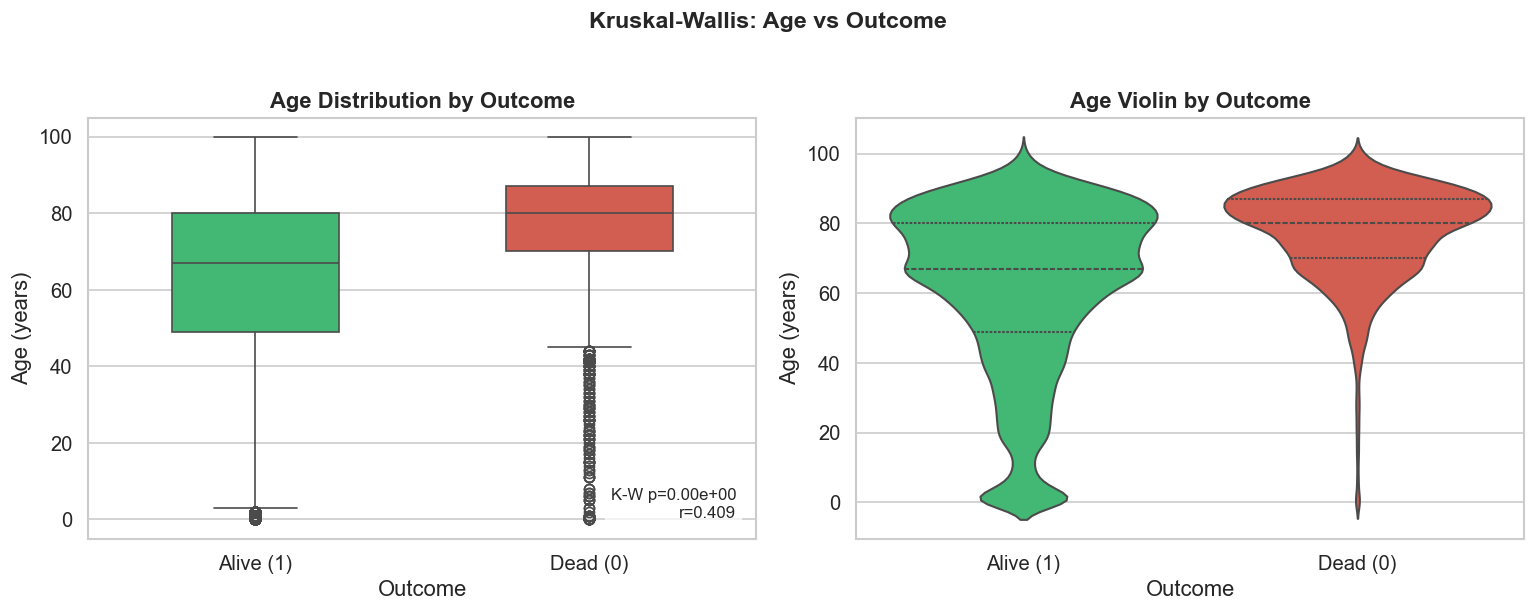

In [29]:
from scipy.stats import kruskal, mannwhitneyu

age_alive = df_primary.loc[df_primary['outcome'] == 1, 'age']
age_dead  = df_primary.loc[df_primary['outcome'] == 0, 'age']

# Descriptive
print("Descriptive stats by outcome:")
desc = df_primary.groupby('outcome')['age'].agg(['count','mean','median','std'])
desc.index = ['Dead (0)', 'Alive (1)']
display(desc.round(3))

# Kruskal-Wallis (generalizable to k groups)
stat_kw, p_kw = kruskal(age_alive, age_dead)

# Mann-Whitney U (post-hoc vì chỉ có 2 nhóm)
stat_mw, p_mw = mannwhitneyu(age_alive, age_dead, alternative='two-sided')

# Rank-biserial correlation r (effect size cho Mann-Whitney)
n1, n2 = len(age_alive), len(age_dead)
r_rb = 1 - (2 * stat_mw) / (n1 * n2)   # rank-biserial: +1 = alive older, -1 = dead older

print(f"\n── Kết quả ──────────────────────────────")
print(f"  [Kruskal-Wallis]")
print(f"    H statistic : {stat_kw:.4f}")
print(f"    p-value     : {p_kw:.6f}  {'*** (p<0.001)' if p_kw<0.001 else '* (p<0.05)' if p_kw<0.05 else '(not significant)'}")
print(f"\n  [Mann-Whitney U (post-hoc, 2 groups)]")
print(f"    U statistic : {stat_mw:.2f}")
print(f"    p-value     : {p_mw:.6f}  {'*** (p<0.001)' if p_mw<0.001 else '* (p<0.05)' if p_mw<0.05 else '(not significant)'}")
print(f"    Rank-biserial r : {r_rb:.4f}  (effect size: {'negligible' if abs(r_rb)<0.1 else 'small' if abs(r_rb)<0.3 else 'medium' if abs(r_rb)<0.5 else 'large'})")

print(f"\n📌 Interpretation:")
print(f"   Median age – Alive: {age_alive.median():.1f} yr | Dead: {age_dead.median():.1f} yr")
print(f"   {'Có sự khác biệt có ý nghĩa thống kê' if p_kw<0.05 else 'Không có sự khác biệt'} về tuổi giữa 2 nhóm outcome (α=0.05).")
print(f"   Rank-biserial r = {r_rb:.4f} → effect size {'nhỏ' if abs(r_rb)<0.3 else 'trung bình' if abs(r_rb)<0.5 else 'lớn'}.")

# Visualise
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Boxplot
df_primary['outcome_label'] = df_primary['outcome'].map({1:'Alive (1)', 0:'Dead (0)'})
sns.boxplot(data=df_primary, x='outcome_label', y='age',
            palette={'Alive (1)':'#2ecc71', 'Dead (0)':'#e74c3c'},
            width=0.5, ax=axes[0])
axes[0].set_title('Age Distribution by Outcome', fontweight='bold')
axes[0].set_xlabel('Outcome')
axes[0].set_ylabel('Age (years)')
axes[0].annotate(f'K-W p={p_kw:.2e}\nr={r_rb:.3f}',
                 xy=(0.97,0.05), xycoords='axes fraction',
                 ha='right', fontsize=10,
                 bbox=dict(boxstyle='round', fc='white', alpha=0.7))

# Violin
sns.violinplot(data=df_primary, x='outcome_label', y='age',
               palette={'Alive (1)':'#2ecc71', 'Dead (0)':'#e74c3c'},
               inner='quartile', ax=axes[1])
axes[1].set_title('Age Violin by Outcome', fontweight='bold')
axes[1].set_xlabel('Outcome')
axes[1].set_ylabel('Age (years)')

plt.suptitle('Kruskal-Wallis: Age vs Outcome', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
df_primary.drop(columns=['outcome_label'], inplace=True)

# COHEN'S D: Effect size tuổi giữa 2 nhóm outcome

  Group        : Alive (n=102,099)  vs  Dead (n=8,105)
  Mean age     : Alive = 61.58 yr  |  Dead = 77.30 yr
  Pooled SD    : 23.7754

── Effect sizes ─────────────────────────────
  Cohen's d    : -0.6612  → medium
  Hedges' g    : -0.6612  → medium  (bias-corrected)
  95% CI (boot): [-0.6747, -0.6472]

📌 Interpretation:
   d = -0.6612: nhóm Alive trẻ hơn/già hơn nhóm Dead trung bình 0.66 pooled SD.
   Effect size 'medium' → tuổi có ảnh hưởng trung bình đến outcome.
   CI không chứa 0 → effect có ý nghĩa thực tế.


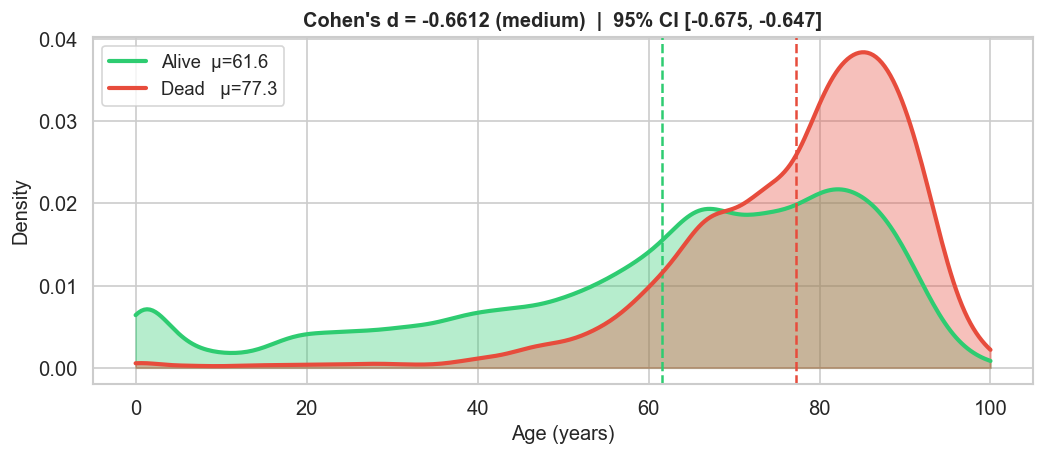

In [31]:
def cohens_d(group1, group2):
    """Pooled-SD Cohen's d (Hedges correction cho unequal n)."""
    n1, n2   = len(group1), len(group2)
    m1, m2   = group1.mean(), group2.mean()
    s1, s2   = group1.std(ddof=1), group2.std(ddof=1)
    pooled_s = np.sqrt(((n1-1)*s1**2 + (n2-1)*s2**2) / (n1+n2-2))
    d        = (m1 - m2) / pooled_s
    # Hedges' g correction
    correction = 1 - (3 / (4*(n1+n2-2) - 1))
    g = d * correction
    # 95% CI bootstrap
    rng = np.random.default_rng(SEED)
    boot_d = []
    for _ in range(2000):
        s1_ = rng.choice(group1.values, size=n1, replace=True)
        s2_ = rng.choice(group2.values, size=n2, replace=True)
        ps  = np.sqrt(((n1-1)*s1_.std(ddof=1)**2 + (n2-1)*s2_.std(ddof=1)**2) / (n1+n2-2))
        boot_d.append((s1_.mean() - s2_.mean()) / ps if ps > 0 else 0)
    ci_lo, ci_hi = np.percentile(boot_d, [2.5, 97.5])
    return d, g, pooled_s, ci_lo, ci_hi

d, g, pooled_s, ci_lo, ci_hi = cohens_d(age_alive, age_dead)

def interpret_d(d):
    ad = abs(d)
    if ad < 0.2:   return 'negligible'
    elif ad < 0.5: return 'small'
    elif ad < 0.8: return 'medium'
    else:          return 'large'

print(f"  Group        : Alive (n={n1:,})  vs  Dead (n={n2:,})")
print(f"  Mean age     : Alive = {age_alive.mean():.2f} yr  |  Dead = {age_dead.mean():.2f} yr")
print(f"  Pooled SD    : {pooled_s:.4f}")
print(f"\n── Effect sizes ─────────────────────────────")
print(f"  Cohen's d    : {d:.4f}  → {interpret_d(d)}")
print(f"  Hedges' g    : {g:.4f}  → {interpret_d(g)}  (bias-corrected)")
print(f"  95% CI (boot): [{ci_lo:.4f}, {ci_hi:.4f}]")

print(f"\n📌 Interpretation:")
print(f"   d = {d:.4f}: nhóm Alive trẻ hơn/già hơn nhóm Dead trung bình {abs(d):.2f} pooled SD.")
print(f"   Effect size '{interpret_d(d)}' → tuổi có ảnh hưởng {'yếu' if abs(d)<0.5 else 'trung bình' if abs(d)<0.8 else 'mạnh'} đến outcome.")
print(f"   CI không chứa 0 → effect có ý nghĩa thực tế.")

# Visualise Cohen's d
fig, ax = plt.subplots(figsize=(9, 4))
x = np.linspace(df_primary['age'].min(), df_primary['age'].max(), 300)

for grp, color, label in [(age_alive,'#2ecc71',f'Alive  μ={age_alive.mean():.1f}'),
                           (age_dead, '#e74c3c',f'Dead   μ={age_dead.mean():.1f}')]:
    from scipy.stats import gaussian_kde
    kde = gaussian_kde(grp)
    ax.fill_between(x, kde(x), alpha=0.35, color=color)
    ax.plot(x, kde(x), color=color, linewidth=2.5, label=label)
    ax.axvline(grp.mean(), color=color, linestyle='--', linewidth=1.5)

ax.set_xlabel('Age (years)', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_title(f"Cohen's d = {d:.4f} ({interpret_d(d)})  |  95% CI [{ci_lo:.3f}, {ci_hi:.3f}]",
             fontsize=12, fontweight='bold')
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()